# Activity 6 Concepts: Holt-Winters Forecasting

Activity 6 asks you to add a forecast to the Demand Explorer, using a `statsmodels` model
called Holt-Winters (the class name in code is `ExponentialSmoothing`). If you have never
touched `statsmodels` before, meeting `.fit()` and `.forecast()` for the first time inside a
`.py` file with no cell output is a rough way to learn what each one actually does.

This notebook walks through the same handful of calls Activity 6 makes, one idea at a time,
with visible output at every step, before you meet them compressed into three lines inside the
app.

Import pandas. Expect no output, the cell just runs.

In [1]:
import pandas as pd

Load `data/nyc_taxi.csv` and resample it to a daily series, exactly as in the Activity 4
and 5 notebooks. Expect a Series of 215 daily totals, one row per calendar day from 2014-07-01
to 2015-01-31.

In [2]:
raw = pd.read_csv("data/nyc_taxi.csv", parse_dates=["timestamp"], index_col="timestamp")
daily = raw["value"].resample("D").sum()
print(len(daily), "days,", daily.index.min().date(), "to", daily.index.max().date())
daily.head()

215 days, 2014-07-01 to 2015-01-31


timestamp
2014-07-01    745967
2014-07-02    733640
2014-07-03    710142
2014-07-04    552565
2014-07-05    555470
Freq: D, Name: value, dtype: int64

## What exponential smoothing is

A forecast needs some rule for turning past values into a guess about tomorrow. Exponential
smoothing's rule is a weighted average of past observations, where recent observations count
more than older ones, and the weight given to each older observation decays the further back
it goes. "Yesterday" moves the forecast more than "three weeks ago" did.

## The three components it tracks

Holt-Winters does not smooth one thing, it tracks three, each captured by its own name:

- **Level**: the current baseline the series is hovering around right now.
- **Trend**: the direction the level itself is drifting, up or down, day over day.
- **Seasonality**: the repeating pattern that comes back on a fixed schedule (here, a weekly
  rhythm: weekdays and weekends behave differently, and that difference repeats every 7 days).

## See the decomposition, not just the description

The three components above are not just descriptive labels, `statsmodels` can pull them apart
and show you each one directly. `seasonal_decompose` splits a series into an observed part, a
trend, a seasonal pattern, and whatever is left over (the residual), without fitting a
forecasting model at all. Run it with `period=7`, the same weekly cycle `seasonal_periods=7`
uses two cells down, for the same reason: this data repeats every 7 daily observations. Expect
four stacked panels: observed, trend, seasonal, resid.

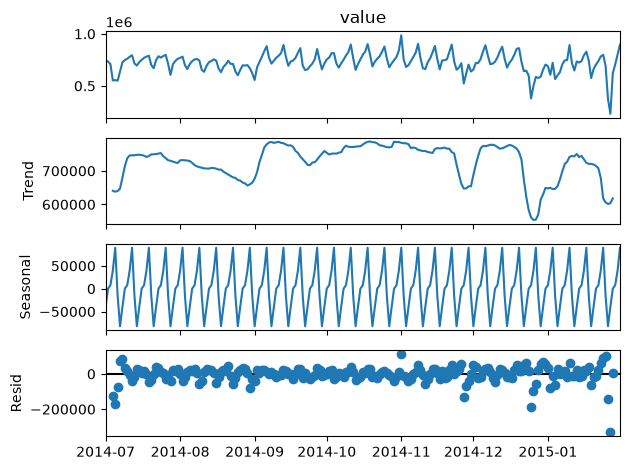

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(daily, model="additive", period=7)
result.plot()
plt.show()

Look at the trend panel closely at the very start and end of the series. Expect `NaN` for the
first three and the last three days: `seasonal_decompose` estimates trend with a centered 7-day
moving average, and a centered window has no full window to average right at the edges of the
series. Hold onto that shape, the Activity 6 app hides a version of this same centered-window
edge problem, and there it does not just leave blank cells, it silently hides a real anomaly.

In [4]:
print(result.trend.head(3))
print(result.trend.tail(3))

timestamp
2014-07-01   NaN
2014-07-02   NaN
2014-07-03   NaN
Freq: D, Name: trend, dtype: float64
timestamp
2015-01-29   NaN
2015-01-30   NaN
2015-01-31   NaN
Freq: D, Name: trend, dtype: float64


Import `ExponentialSmoothing` from `statsmodels.tsa.holtwinters`, and construct it on the
full daily series with `trend="add", seasonal="add", seasonal_periods=7`. `seasonal_periods=7`
tells it plainly: this data is daily, and the pattern repeats every 7 observations, one week.
Expect no forecast yet, just a model object. Print its type to confirm that: a model, not a set
of numbers.

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(daily, trend="add", seasonal="add", seasonal_periods=7)
type(model)

statsmodels.tsa.holtwinters.model.ExponentialSmoothing

`.fit()` in its own cell. Fitting is where the model looks at all 215 days of history and
ESTIMATES the level, trend, and seasonal numbers that best explain what already happened.
Expect a *different kind* of object back, a fitted results object, not a forecast and not a
table of numbers. This is the split that trips people up most: `.fit()` estimates parameters
from history, it does not by itself produce a single future value.

In [6]:
fitted = model.fit()
type(fitted)

statsmodels.tsa.holtwinters.results.HoltWintersResultsWrapper

`.forecast(horizon)` in its own cell. `horizon` is simply how many future periods you want
back. Ask for 14 more days beyond the last day the model saw. Expect a Series of 14 new dates
continuing past 2015-01-31, each one a predicted ride count.

In [7]:
forecast = fitted.forecast(14)
forecast.head()

2015-02-01    752494.713025
2015-02-02    655809.994567
2015-02-03    710529.337776
2015-02-04    784457.994806
2015-02-05    782500.591651
Freq: D, dtype: float64

Plot the history and the forecast together so you can see the forecast continue the same
weekly up-and-down shape as the real data, rather than flattening out into a straight line.
Expect the forecast segment to keep wiggling on a 7-day rhythm that matches the pattern right
before it.

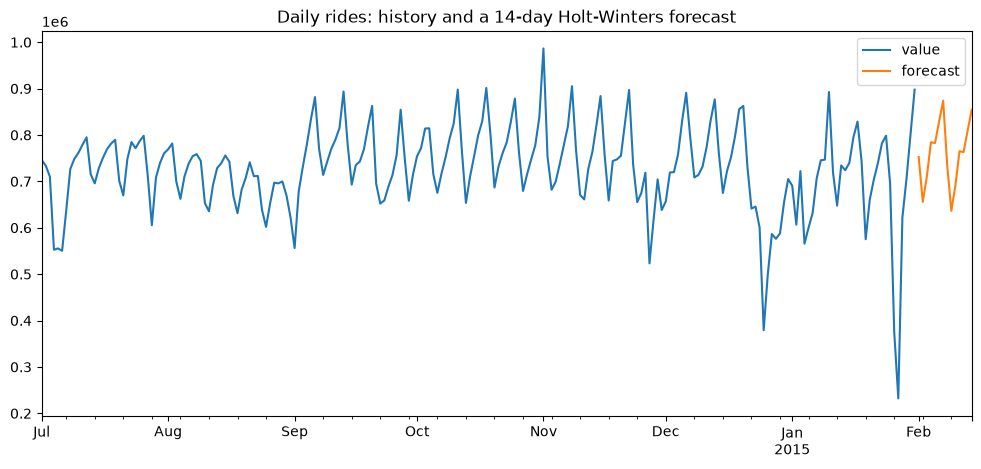

In [8]:
import matplotlib.pyplot as plt

pd.concat([daily, forecast.rename("forecast")], axis=1).plot(
    figsize=(12, 5),
    title="Daily rides: history and a 14-day Holt-Winters forecast",
)
plt.show()

## Is the forecast any good? An honest test

Everything above fit the model on all 215 days and then forecast into days that do not exist
yet in this file, so there was nothing to check the forecast against. To actually test it, hide
the last 31 days from the model: fit on data only through 2014-12-31, then forecast 31 days
forward. Those 31 forecast days land exactly on real days that are already sitting in `daily`,
so the forecast can be compared against what really happened.

Expect the first three forecast values to land close to 640,527 / 769,368 / 837,933.

In [9]:
train = daily.loc[:"2014-12-31"]
fit_train = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7).fit()
future = fit_train.forecast(31)
future.head(3)

2015-01-01    640527.249793
2015-01-02    769367.882264
2015-01-03    837932.738506
Freq: D, dtype: float64

Put the forecast next to what actually happened on those same 31 days. Expect the two
columns to sit close together on ordinary days, and to pull apart wherever something unusual
happened, since the model only knows the shape of a typical week, not any specific future
event.

In [10]:
comparison = pd.DataFrame({"actual": daily.loc[future.index], "forecast": future})
comparison["difference"] = comparison["actual"] - comparison["forecast"]
comparison

,actual,forecast,difference
2015-01-01,690407,640527.249793,49879.750207
2015-01-02,606716,769367.882264,-162651.882264
2015-01-03,722115,837932.738506,-115817.738506
2015-01-04,565709,761346.657986,-195637.657986
2015-01-05,600132,692942.365413,-92810.365413
2015-01-06,631877,704852.202400,-72975.202400
2015-01-07,707015,681924.400069,25090.599931
2015-01-08,745416,638869.871429,106546.128571
2015-01-09,746839,767710.503899,-20871.503899
2015-01-10,892664,836275.360141,56388.639859


Plot the same comparison, with the training history behind it for context. Expect the
forecast line to track the actual line reasonably well through most of January, then split
sharply away from it for a day or two near the end of the month.

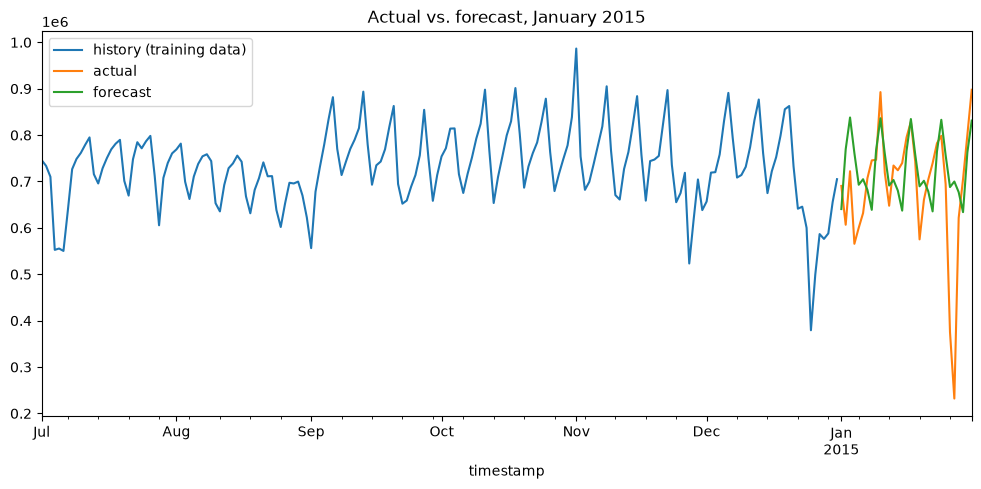

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, label="history (training data)")
comparison["actual"].plot(ax=ax, label="actual")
comparison["forecast"].plot(ax=ax, label="forecast")
ax.set_title("Actual vs. forecast, January 2015")
ax.legend()
plt.show()

Look closely at the days where the split was biggest. Expect the actual value to fall far
below the forecast on 2015-01-26 and 2015-01-27.

In [12]:
comparison.loc["2015-01-25":"2015-01-28"]

,actual,forecast,difference
2015-01-25,694262,756374.522892,-62112.522892
2015-01-26,375311,687970.230319,-312659.230319
2015-01-27,232058,699880.067306,-467822.067306
2015-01-28,621483,676952.264975,-55469.264975


A major winter storm shut down much of New York City on January 26 and 27, 2015.
Holt-Winters has no way to know that was coming. It only knows "late-January weekdays tend to
look like this," learned from patterns in the history it was given, and a blizzard is not a
pattern, it is an event. This is exactly why Activity 6 does not stop at forecasting: it also
detects anomalies, the days where the ACTUAL value breaks far enough from a rolling baseline to
be worth a person's attention, precisely like January 26-27 would be flagged.

## One caution before you reuse this

`seasonal_periods=7` is doing real work here because this data genuinely has a clean weekly
rhythm: rides behave differently on a Saturday than a Tuesday, and that difference repeats
every 7 days without fail. That same setting is NOT appropriate for every daily series. A stock
ticker, for example, is closed on weekends and holidays and has no clean 7-day repeating shape
underneath it, so forcing `seasonal_periods=7` onto it would fit a pattern that is not really
there. Match `seasonal_periods` to a real, known cycle in the data, or leave `seasonal` out
entirely when no such cycle exists.

**Try changing this and re-run, no new code needed:**

1. In the honest-test cell, change `seasonal_periods=7` to `seasonal_periods=14` and re-run
   that cell plus the comparison table after it. Does the forecast track late January better,
   worse, or about the same?
2. In the first forecast cell, change `fitted.forecast(14)` to `fitted.forecast(60)` and
   re-run it and the plot after it. How far out does the weekly wiggle still look like a
   believable forecast to your eye, and where does it start to look like it is just repeating
   itself?